<a href="https://colab.research.google.com/github/hamshini1413/hamshini_gen_ai_foundation/blob/main/10_Denoising_Diffusion_Probabilistic_Model_(DDPM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Shape : torch.Size([1, 3, 64, 64])
Noisy Shape    : torch.Size([1, 3, 64, 64])


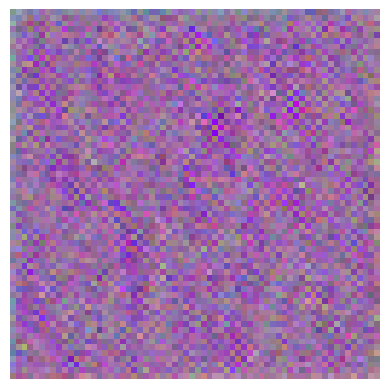

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
IMAGE_SIZE = 64
TIMESTEPS = 1000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Linear Noise Scheduler
# ----------------------------
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, TIMESTEPS).to(DEVICE)

alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

# ----------------------------
# Forward Diffusion
# q(x_t | x_0)
# ----------------------------
def forward_diffusion(x0, t):

    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(alpha_bar[t])[:, None, None, None]
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar[t])[:, None, None, None]

    xt = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

    return xt, noise

# ----------------------------
# Simple Noise Prediction Model
# ----------------------------
class SimpleUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,3,3,padding=1)

        )

    def forward(self,x,t):
        return self.net(x)

model = SimpleUNet().to(DEVICE)

# ----------------------------
# Reverse Diffusion
# p_theta(x_{t-1}|x_t)
# ----------------------------
@torch.no_grad()
def reverse_diffusion(model):

    x = torch.randn((1,3,IMAGE_SIZE,IMAGE_SIZE)).to(DEVICE)

    for t in reversed(range(TIMESTEPS)):

        beta = betas[t]
        alpha = alphas[t]
        alpha_bar_t = alpha_bar[t]

        predicted_noise = model(x, torch.tensor([t]).to(DEVICE))

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
        ) * (
            x - ((1-alpha)/torch.sqrt(1-alpha_bar_t))*predicted_noise
        ) + torch.sqrt(beta)*z

    return x

# ----------------------------
# Example Forward Process
# ----------------------------
x0 = torch.rand((1,3,IMAGE_SIZE,IMAGE_SIZE)).to(DEVICE)

t = torch.randint(0,TIMESTEPS,(1,)).to(DEVICE)

xt, noise = forward_diffusion(x0,t)

print("Original Shape :", x0.shape)
print("Noisy Shape    :", xt.shape)

# ----------------------------
# Generate Image
# ----------------------------
generated = reverse_diffusion(model)

image = generated.squeeze().permute(1,2,0).cpu().numpy()

image = (image-image.min())/(image.max()-image.min())

plt.imshow(image)
plt.axis("off")
plt.show()